# Processamento de Imagens de Satélite: Índices Espectrais e Detecção de Mudanças

Nesta aula vamos colocar em prática o que aprendemos sobre STAC para investigar um evento real: **o rompimento da barragem de rejeitos da Vale em Brumadinho (MG)**, ocorrido em 25 de janeiro de 2019.

Vamos:
1. Buscar imagens CBERS-4/MUX de **antes** e **depois** do rompimento;
2. Calcular índices espectrais (**NDVI**, **NDWI** e **EVI**);
3. Analisar o histograma desses índices;
4. Classificar a imagem por limiares (thresholding);
5. Calcular a **diferença entre as duas datas** para visualizar o impacto do desastre.

> Como vimos na aula anterior, imagens de satélite consomem bastante RAM. Vamos reaproveitar a função `check_memory` para acompanhar o uso de memória ao longo do notebook.

In [1]:
from pystac_client import Client
import rasterio
from rasterio.windows import from_bounds
from pyproj import Transformer
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import psutil

In [2]:
def check_memory(label: str = "", warn_threshold: float = 85.0) -> None:
    """Imprime o uso atual de RAM e alerta se estiver perto do limite da máquina."""
    mem = psutil.virtual_memory()
    used_gb = mem.used / (1024 ** 3)
    total_gb = mem.total / (1024 ** 3)
    available_gb = mem.available / (1024 ** 3)

    prefix = f"[RAM] {label}: " if label else "[RAM] "
    print(f"{prefix}{used_gb:.2f} GB usados de {total_gb:.2f} GB ({mem.percent:.1f}%) | disponível: {available_gb:.2f} GB")

    if mem.percent >= warn_threshold:
        print(f"ATENÇÃO: uso de RAM acima de {warn_threshold:.0f}%! Considere reiniciar o kernel "
              "ou reduzir a área de interesse (bbox/window).")

check_memory("início do notebook")

[RAM] início do notebook: 10.55 GB usados de 32.00 GB (70.0%) | disponível: 9.60 GB


## 1. Buscando as imagens no STAC

Vamos usar o catálogo do Brazil Data Cube (o mesmo da aula passada) e buscar cenas CBERS-4/MUX (`CB4-MUX-L4-SR-1`) sobre a região da barragem, tanto **antes** quanto **depois** de 25/01/2019.

Área de interesse: entorno da mina Córrego do Feijão / Brumadinho-MG.

In [3]:
cbers_stac = "https://data.inpe.br/bdc/stac/v1/"
client = Client.open(cbers_stac)

# bbox aproximado cobrindo a barragem de Brumadinho / Córrego do Feijão
bbox = [-44.22, -20.17, -44.05, -20.05]

In [4]:
search_antes = client.search(
    collections=["CB4-MUX-L4-SR-1"],
    bbox=bbox,
    datetime="2018-10-01/2019-01-24",
    query={"eo:cloud_cover": {"lt": 30}}
)

search_depois = client.search(
    collections=["CB4-MUX-L4-SR-1"],
    bbox=bbox,
    datetime="2019-01-26/2019-04-30",
    query={"eo:cloud_cover": {"lt": 30}}
)

print("Imagens antes do rompimento:", search_antes.matched())
for item in search_antes.items():
    print(" ", item.id, "- nuvens:", round(item.properties["eo:cloud_cover"], 1), "%")

print("\nImagens depois do rompimento:", search_depois.matched())
for item in search_depois.items():
    print(" ", item.id, "- nuvens:", round(item.properties["eo:cloud_cover"], 1), "%")

Imagens antes do rompimento: 4


  CBERS_4_MUX_20181214_153_122_L4 - nuvens: 3.2 %
  CBERS_4_MUX_20181214_153_123_L4 - nuvens: 4.1 %
  CBERS_4_MUX_20181023_153_122_L4 - nuvens: 1.4 %
  CBERS_4_MUX_20181023_153_123_L4 - nuvens: 7.1 %



Imagens depois do rompimento: 5


  CBERS_4_MUX_20190429_152_123_L4 - nuvens: 29.3 %
  CBERS_4_MUX_20190426_153_122_L4 - nuvens: 0.9 %
  CBERS_4_MUX_20190426_153_123_L4 - nuvens: 5.9 %
  CBERS_4_MUX_20190328_153_122_L4 - nuvens: 15.2 %
  CBERS_4_MUX_20190328_153_123_L4 - nuvens: 17.6 %


Vamos escolher duas cenas da **mesma órbita/tile** (mesmo enquadramento), uma de cada período, com baixa cobertura de nuvens — assim os pixels ficam alinhados e dá para comparar diretamente.

In [5]:
item_antes = list(client.search(collections=["CB4-MUX-L4-SR-1"], ids=["CBERS_4_MUX_20181023_153_122_L4"]).items())[0]
item_depois = list(client.search(collections=["CB4-MUX-L4-SR-1"], ids=["CBERS_4_MUX_20190522_153_122_L4"]).items())[0]

print(item_antes)
print(item_depois)

<Item id=CBERS_4_MUX_20181023_153_122_L4>
<Item id=CBERS_4_MUX_20190522_153_122_L4>


## 2. Lendo as bandas por janela (window)

Como aprendemos na aula anterior, não precisamos baixar a cena inteira — vamos ler só a janela correspondente à nossa área de interesse, o que também economiza RAM.

In [6]:
def read_window(uri: str, bbox: list, masked: bool = True) -> np.ma.MaskedArray:
    """Lê a janela do raster correspondente ao bbox (em EPSG:4326)."""
    with rasterio.open(uri) as src:
        transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
        minx, miny = transformer.transform(bbox[0], bbox[1])
        maxx, maxy = transformer.transform(bbox[2], bbox[3])
        window = from_bounds(minx, miny, maxx, maxy, src.transform).round_offsets().round_lengths()
        return src.read(1, window=window, masked=masked)


def read_bands(item, bbox):
    """Lê as bandas azul, verde, vermelho e NIR (MUX: BAND5, 6, 7, 8) para um item STAC."""
    assets = item.assets
    blue = read_window(assets["BAND5"].href, bbox).astype("float32")
    green = read_window(assets["BAND6"].href, bbox).astype("float32")
    red = read_window(assets["BAND7"].href, bbox).astype("float32")
    nir = read_window(assets["BAND8"].href, bbox).astype("float32")
    return blue, green, red, nir

In [7]:
blue_antes, green_antes, red_antes, nir_antes = read_bands(item_antes, bbox)
check_memory("depois de ler as bandas de 'antes'")

blue_depois, green_depois, red_depois, nir_depois = read_bands(item_depois, bbox)
check_memory("depois de ler as bandas de 'depois'")

print("shape:", red_antes.shape)

[RAM] depois de ler as bandas de 'antes': 10.65 GB usados de 32.00 GB (70.1%) | disponível: 9.57 GB


[RAM] depois de ler as bandas de 'depois': 10.57 GB usados de 32.00 GB (69.9%) | disponível: 9.63 GB
shape: (659, 892)


## 3. Composição RGB verdadeira: antes x depois

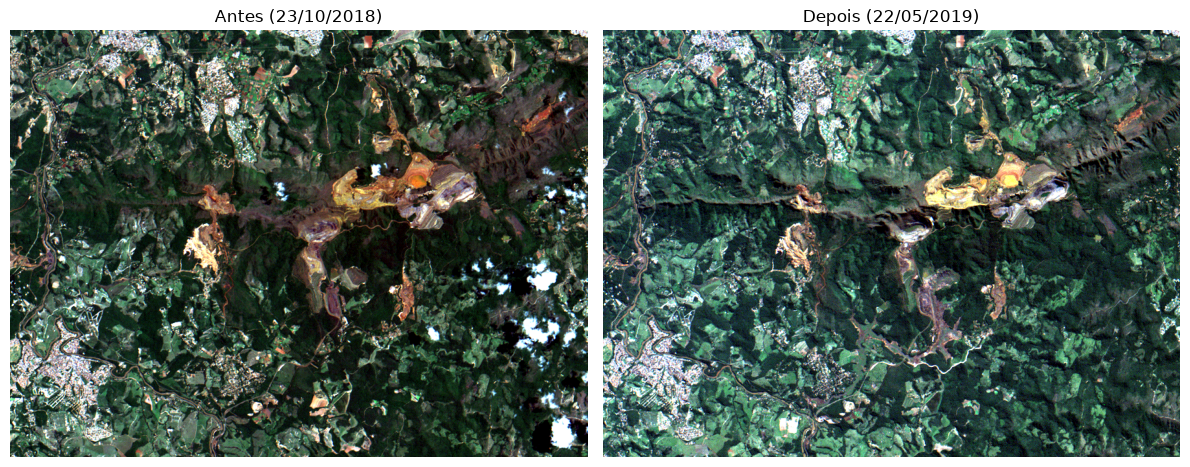

In [8]:
def normalize(array, lo_pct=2, hi_pct=98):
    """Normaliza um array numpy usando um contraste por percentil (mais robusto a outliers/ruído do sensor)"""
    data = np.ma.filled(array, np.nan).astype("float64")
    valid = data[np.isfinite(data)]
    p_lo, p_hi = np.percentile(valid, [lo_pct, hi_pct])
    normalized = (array - p_lo) / (p_hi - p_lo)
    return np.clip(normalized, 0, 1)


def make_rgb(red, green, blue):
    return np.dstack((normalize(red), normalize(green), normalize(blue)))


rgb_antes = make_rgb(red_antes, green_antes, blue_antes)
rgb_depois = make_rgb(red_depois, green_depois, blue_depois)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(rgb_antes)
ax1.set_title("Antes (23/10/2018)")
ax1.axis("off")
ax2.imshow(rgb_depois)
ax2.set_title("Depois (22/05/2019)")
ax2.axis("off")
plt.tight_layout()
plt.show()

## 4. Índices espectrais

Agora vamos calcular três índices amplamente usados em sensoriamento remoto:

- **NDVI** (Normalized Difference Vegetation Index): saúde/vigor da vegetação
- **NDWI** (Normalized Difference Water Index): presença de água/umidade
- **EVI** (Enhanced Vegetation Index): parecido com o NDVI, mas corrige efeitos atmosféricos e de solo

In [9]:
def calc_ndvi(nir, red):
    """NDVI = (NIR - RED) / (NIR + RED)"""
    with np.errstate(divide="ignore", invalid="ignore"):
        return (nir - red) / (nir + red)


def calc_ndwi(green, nir):
    """NDWI (McFeeters) = (GREEN - NIR) / (GREEN + NIR)"""
    with np.errstate(divide="ignore", invalid="ignore"):
        return (green - nir) / (green + nir)


def calc_evi(nir, red, blue, G=2.5, C1=6, C2=7.5, L=1):
    """EVI = G * (NIR - RED) / (NIR + C1*RED - C2*BLUE + L)"""
    with np.errstate(divide="ignore", invalid="ignore"):
        return G * (nir - red) / (nir + C1 * red - C2 * blue + L)

In [10]:
ndvi_antes = calc_ndvi(nir_antes, red_antes)
ndvi_depois = calc_ndvi(nir_depois, red_depois)

ndwi_antes = calc_ndwi(green_antes, nir_antes)
ndwi_depois = calc_ndwi(green_depois, nir_depois)

evi_antes = calc_evi(nir_antes, red_antes, blue_antes)
evi_depois = calc_evi(nir_depois, red_depois, blue_depois)

check_memory("depois de calcular os índices")

[RAM] depois de calcular os índices: 10.69 GB usados de 32.00 GB (70.2%) | disponível: 9.52 GB


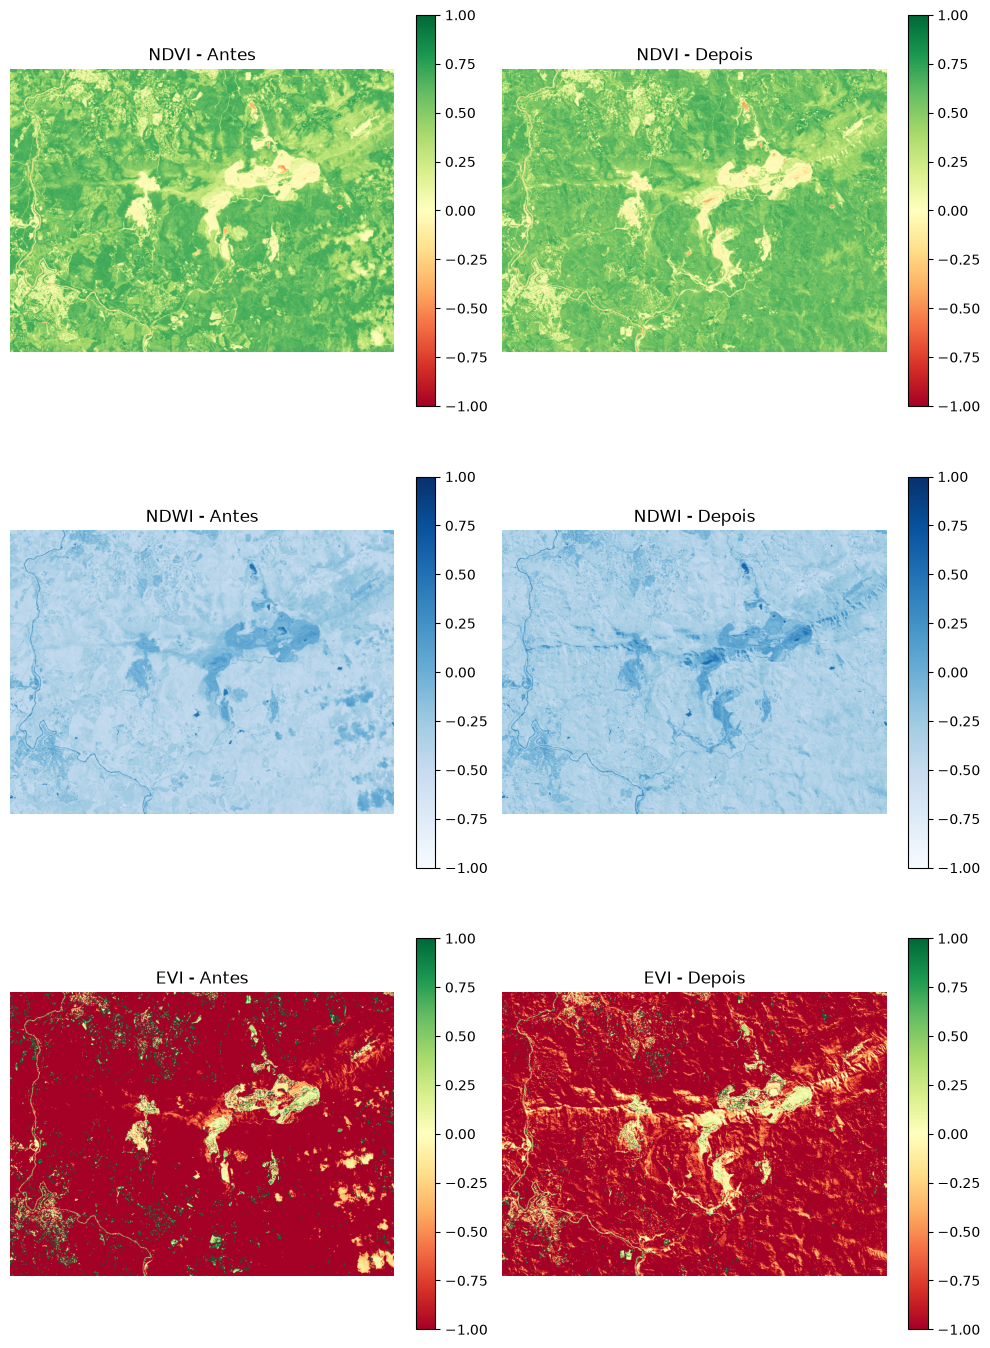

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(10, 14))

for ax, data, title in zip(axes[0], [ndvi_antes, ndvi_depois], ["NDVI - Antes", "NDVI - Depois"]):
    im = ax.imshow(data, cmap="RdYlGn", vmin=-1, vmax=1)
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)

for ax, data, title in zip(axes[1], [ndwi_antes, ndwi_depois], ["NDWI - Antes", "NDWI - Depois"]):
    im = ax.imshow(data, cmap="Blues", vmin=-1, vmax=1)
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)

for ax, data, title in zip(axes[2], [evi_antes, evi_depois], ["EVI - Antes", "EVI - Depois"]):
    im = ax.imshow(data, cmap="RdYlGn", vmin=-1, vmax=1)
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

## 5. Histograma

O histograma mostra como os valores do índice estão distribuídos na imagem. Vamos olhar o NDVI de antes do rompimento.

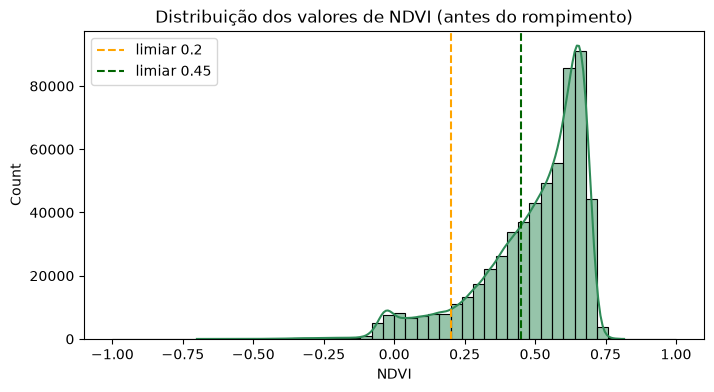

In [12]:
ndvi_flat = np.ma.filled(ndvi_antes, np.nan).ravel()
ndvi_flat = ndvi_flat[np.isfinite(ndvi_flat)]

plt.figure(figsize=(8, 4))
sns.histplot(ndvi_flat, kde=True, color="seagreen", binrange=(-1, 1), bins=50)
plt.axvline(0.2, color="orange", linestyle="--", label="limiar 0.2")
plt.axvline(0.45, color="darkgreen", linestyle="--", label="limiar 0.45")
plt.title("Distribuição dos valores de NDVI (antes do rompimento)")
plt.xlabel("NDVI")
plt.legend()
plt.show()

## 6. Classificação por limiar (thresholding)

Com base no histograma, podemos definir limiares para classificar a imagem em classes. Para o NDVI:

- `< 0.2`: solo exposto / água / área urbana
- `0.2 – 0.45`: vegetação esparsa/fraca
- `>= 0.45`: vegetação vigorosa

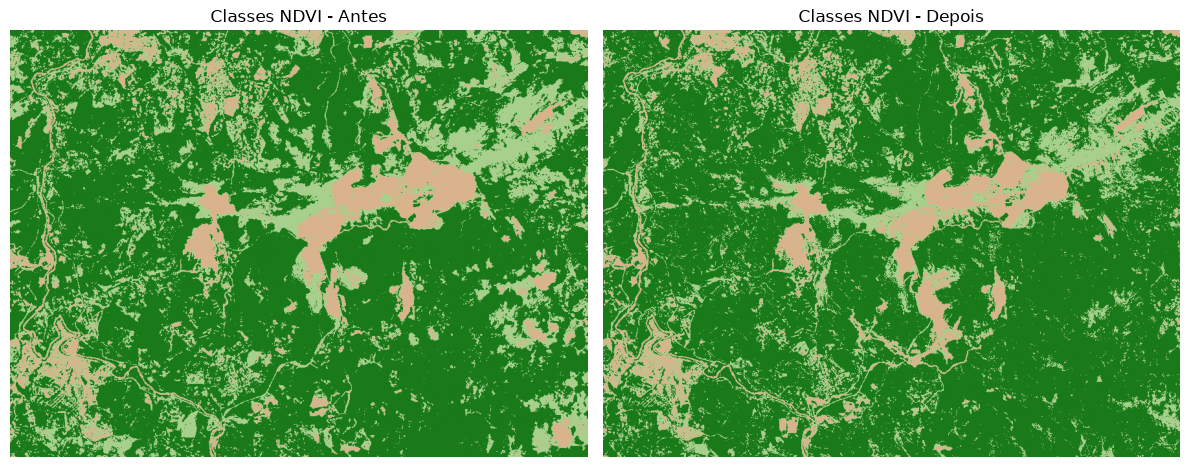

In [13]:
def classify_ndvi(ndvi):
    """0 = sem dado, 1 = solo/água/urbano, 2 = vegetação fraca, 3 = vegetação vigorosa"""
    ndvi_filled = np.ma.filled(ndvi, np.nan)
    classes = np.zeros_like(ndvi_filled, dtype=np.int8)
    classes[ndvi_filled < 0.2] = 1
    classes[(ndvi_filled >= 0.2) & (ndvi_filled < 0.45)] = 2
    classes[ndvi_filled >= 0.45] = 3
    return classes


classes_antes = classify_ndvi(ndvi_antes)
classes_depois = classify_ndvi(ndvi_depois)

cmap = ListedColormap(["black", "#d9b38c", "#a8d08d", "#1a7a1a"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(classes_antes, cmap=cmap, vmin=0, vmax=3)
ax1.set_title("Classes NDVI - Antes")
ax1.axis("off")
ax2.imshow(classes_depois, cmap=cmap, vmin=0, vmax=3)
ax2.set_title("Classes NDVI - Depois")
ax2.axis("off")
plt.tight_layout()
plt.show()

## 7. Diferença entre as imagens (antes x depois)

Agora o mais importante: subtraindo o NDVI de depois pelo de antes, conseguimos visualizar exatamente onde a vegetação foi destruída pela onda de rejeitos. Valores bem negativos (azul) indicam perda de vegetação/solo coberto pela lama.

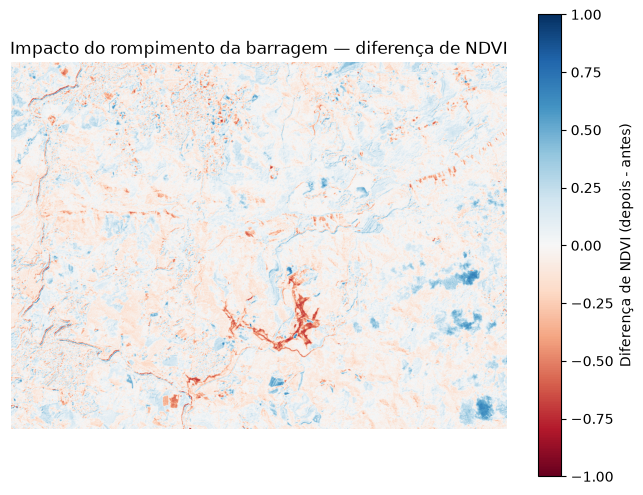

Diferença média de NDVI: -0.0029783437
Pixels com forte perda de vegetação (diff < -0.3): 12875


In [14]:
ndvi_diff = np.ma.filled(ndvi_depois, np.nan) - np.ma.filled(ndvi_antes, np.nan)

plt.figure(figsize=(8, 6))
im = plt.imshow(ndvi_diff, cmap="RdBu", vmin=-1, vmax=1)
plt.colorbar(im, label="Diferença de NDVI (depois - antes)")
plt.title("Impacto do rompimento da barragem — diferença de NDVI")
plt.axis("off")
plt.show()

print("Diferença média de NDVI:", np.nanmean(ndvi_diff))
print("Pixels com forte perda de vegetação (diff < -0.3):", np.sum(ndvi_diff < -0.3))

## 8. E a água?

O rejeito de mineração se comporta de forma parecida com água/lama nas bandas espectrais. Vamos ver a diferença de NDWI também, que pode evidenciar a lama e o assoreamento do Rio Paraopeba.

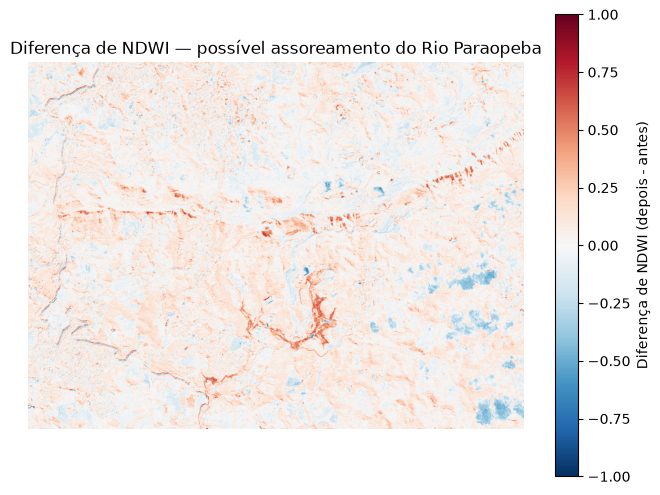

[RAM] fim do notebook: 10.73 GB usados de 32.00 GB (70.4%) | disponível: 9.48 GB


In [15]:
ndwi_diff = np.ma.filled(ndwi_depois, np.nan) - np.ma.filled(ndwi_antes, np.nan)

plt.figure(figsize=(8, 6))
im = plt.imshow(ndwi_diff, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, label="Diferença de NDWI (depois - antes)")
plt.title("Diferença de NDWI — possível assoreamento do Rio Paraopeba")
plt.axis("off")
plt.show()

check_memory("fim do notebook")

# Referências

- [Brazil Data Cube - stac-image-processing.ipynb](https://github.com/brazil-data-cube/code-gallery/blob/master/jupyter/Python/stac/stac-image-processing.ipynb)
- Catálogo STAC: [https://data.inpe.br/bdc/stac/v1/](https://data.inpe.br/bdc/stac/v1/)